<a href="https://colab.research.google.com/github/noorchouman/ecommerce-sales-analysis/blob/main/E_commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Section 1: Setup & imports


In [ ]:

!pip install pandas numpy matplotlib seaborn scikit-learn scipy psycopg2-binary

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix
)

from scipy.stats import ttest_ind

sns.set_theme(style="whitegrid")

from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Section 2:Importing dataset


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DataScienceProject/datads.csv', encoding='ISO-8859-1')
df.head()

df.info()
df.describe()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
print("Raw dataset sample:")
display(df.head())




Raw dataset sample:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


##Section 3: Data Cleaning

This dataset contains online retail transaction records, and like most real-world data, it includes:

Missing values

Duplicates

Incorrect formats

Negative prices and quantities (returns)

In [ ]:


import pandas as pd
import numpy as np

# 1. Standardize column names (remove spaces, unify formatting)
df.columns = df.columns.str.strip()


# 2. Drop missing CustomerID

print("Missing values per column before cleaning:")
print(df.isna().sum())

df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)

print("\nRemaining rows after dropping missing CustomerID:", df.shape[0])




Missing values per column before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Remaining rows after dropping missing CustomerID: 406829


In [ ]:
# 3. Drop missing product descriptions ()

df = df.dropna(subset=["Description"])

df["Description"] = (
    df["Description"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("Rows remaining after cleaning Description:", df.shape[0])

#The product description is necessary for understanding product demand and trends.
#We clean descriptions by:

#Removing extra spaces

#Standardizing to lowercase

#Ensuring consistent product naming



Rows remaining after cleaning Description: 406829


In [ ]:
# 4. Fix dates and invalid rows

# Convert InvoiceDate to datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Remove rows where conversion failed
df = df.dropna(subset=["InvoiceDate"])

print("Date conversion complete. Example:")
print(df["InvoiceDate"].head())


Date conversion complete. Example:
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]


In [ ]:
#5. Remove negative quantities (returns) and invalid prices


numeric_df = df.select_dtypes(include=[np.number])
print("Negative values per numeric column:")
print((numeric_df < 0).sum())

df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

print("\nRemaining rows after removing negatives:", df.shape[0])

#Negative quantities represent returns or canceled transactions.
#Negative or zero prices are invalid entries.
#These rows would distort:

#Revenue analysis

#Top-selling products

#Customer spending

#Model training

#So they are removed.


Negative values per numeric column:
Quantity      8905
UnitPrice        0
CustomerID       0
dtype: int64

Remaining rows after removing negatives: 397884


In [ ]:
#6. Removing duplicate rows

duplicates = df.duplicated().sum()
print("Duplicate rows found:", duplicates)

df = df.drop_duplicates()

print("Remaining rows after removing duplicates:", df.shape[0])


Duplicate rows found: 5192
Remaining rows after removing duplicates: 392692


In [ ]:
#7. Create sales and time-based features

df["Sales"] = df["Quantity"] * df["UnitPrice"]

df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
df["InvoiceDay"] = df["InvoiceDate"].dt.date
df["InvoiceHour"] = df["InvoiceDate"].dt.hour

print(df.head())

##These features will be used later for: EDA visualizations-SQL queries-Time-based trends-Tableau dashboard-RFM Recency calculation

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   white hanging heart t-light holder         6   
1    536365     71053                  white metal lantern         6   
2    536365    84406B       cream cupid hearts coat hanger         8   
3    536365    84029G  knitted union flag hot water bottle         6   
4    536365    84029E       red woolly hottie white heart.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Sales  \
0 2010-12-01 08:26:00       2.55       17850  United Kingdom  15.30   
1 2010-12-01 08:26:00       3.39       17850  United Kingdom  20.34   
2 2010-12-01 08:26:00       2.75       17850  United Kingdom  22.00   
3 2010-12-01 08:26:00       3.39       17850  United Kingdom  20.34   
4 2010-12-01 08:26:00       3.39       17850  United Kingdom  20.34   

  InvoiceMonth  InvoiceDay  InvoiceHour  
0      2010-12  2010-12-01            8  
1      2010-12  2010-12-01            8  
2      2010-12

In [ ]:
##Final Check

print("Final missing values:")
print(df.isna().sum())

print("\nFinal dataset shape:", df.shape)
df.head()
df.to_csv("ecommerce_clean.csv", index=False)



Final missing values:
InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
Sales           0
InvoiceMonth    0
InvoiceDay      0
InvoiceHour     0
dtype: int64

Final dataset shape: (392692, 12)


##Section 4: Exploratory Data Analysis (EDA)
###Monthly Revenue Trend

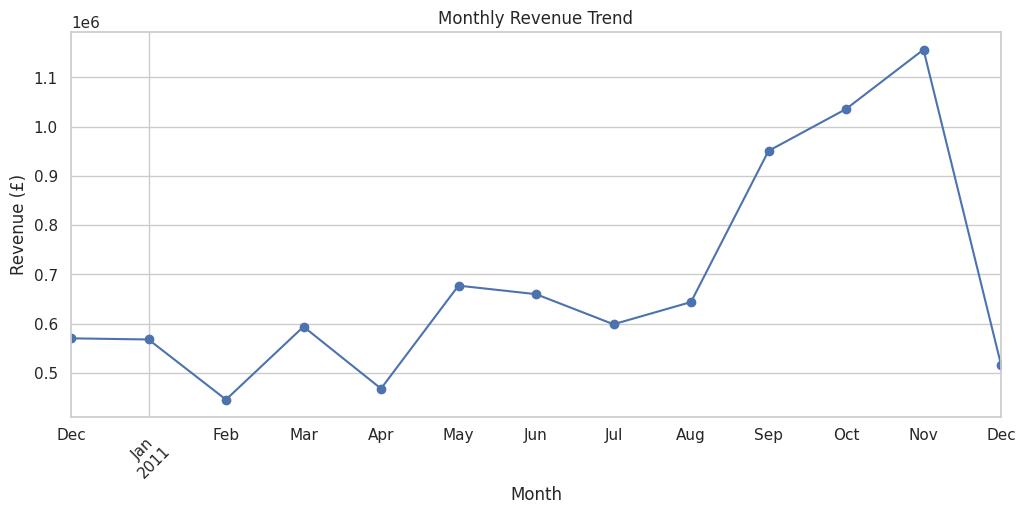

In [ ]:
# Ensure InvoiceDate is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create a monthly period column
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Monthly revenue (sum of Sales)
monthly_revenue = df.groupby('Month')['Sales'].sum()

# Plot
plt.figure(figsize=(12,5))
monthly_revenue.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


###Monthly Sales Volume

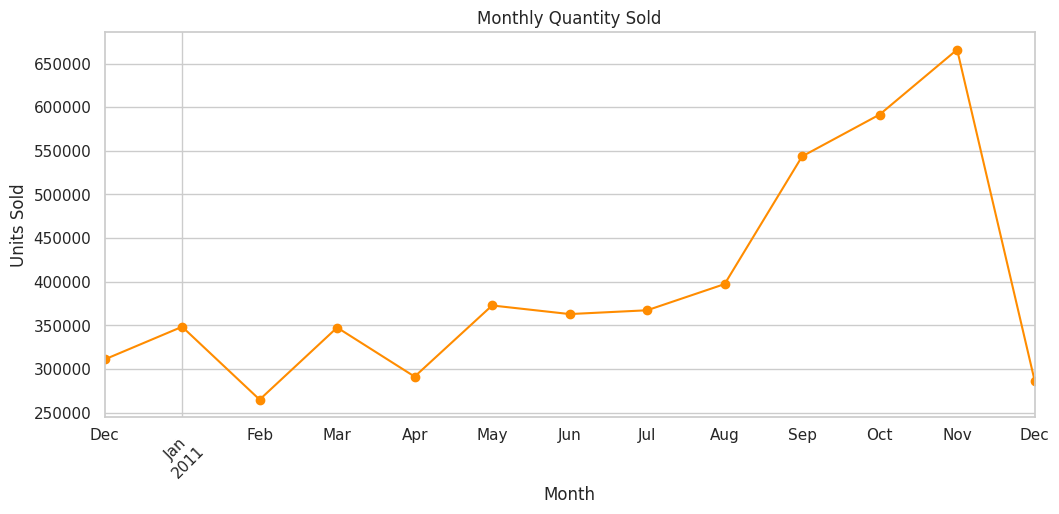

In [ ]:
# Monthly total quantity sold
monthly_units = df.groupby('Month')['Quantity'].sum()

plt.figure(figsize=(12,5))
monthly_units.plot(marker='o', color='darkorange')
plt.title("Monthly Quantity Sold")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


###Monthly Active Customers

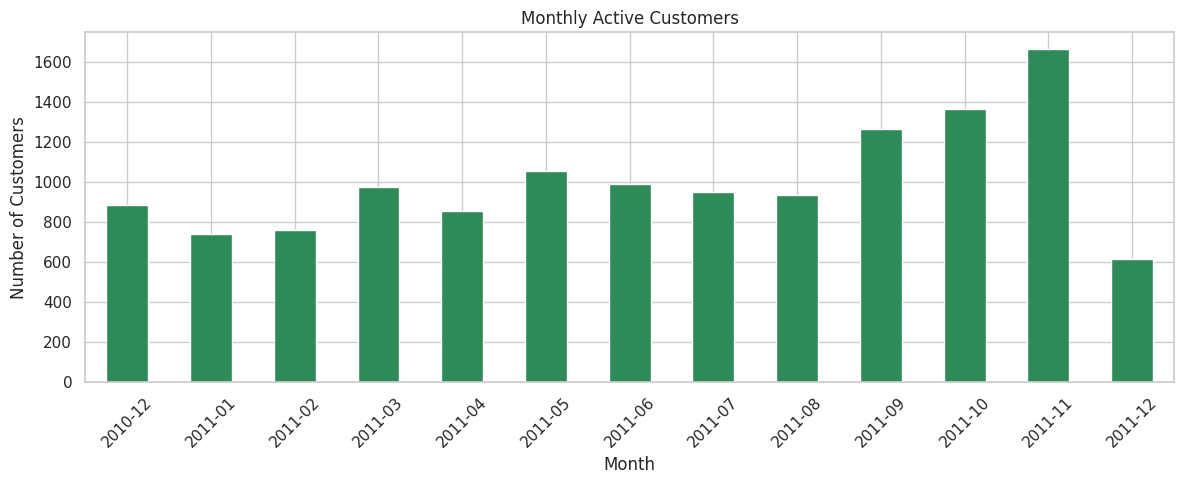

In [ ]:
monthly_active = df.groupby('Month')['CustomerID'].nunique()

plt.figure(figsize=(12,5))
monthly_active.plot(kind='bar', color='seagreen')
plt.title("Monthly Active Customers")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


###Total Sales by day of week

/tmp/ipython-input-3237690152.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_day.index, y=sales_by_day.values, palette='viridis')


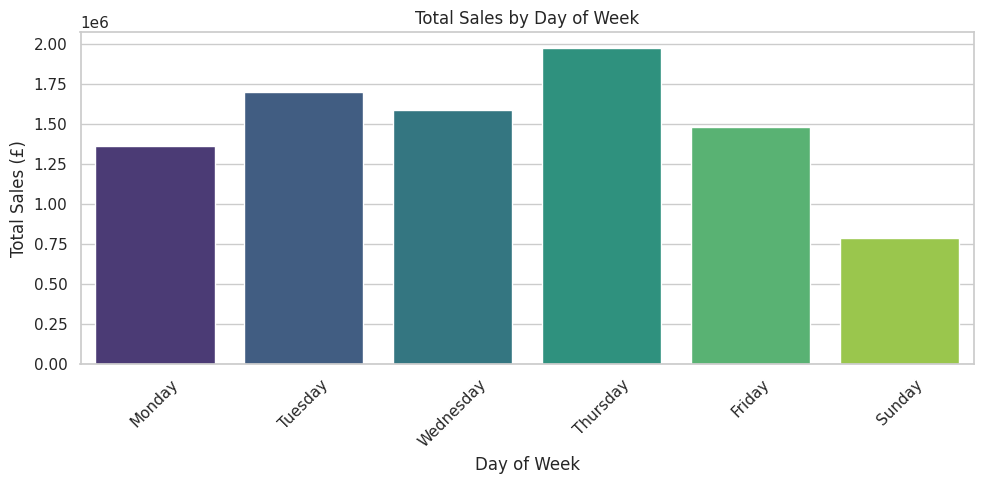

In [ ]:
# Ensure InvoiceDate is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create a day of week column
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

# Calculate total sales per day
sales_by_day = df.groupby('DayOfWeek')['Sales'].sum()

# Correct order
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Keep only days that exist in your data
order_existing = [d for d in order if d in sales_by_day.index]

# Reorder
sales_by_day = sales_by_day.loc[order_existing]

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=sales_by_day.index, y=sales_by_day.values, palette='viridis')
plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


###Top products by revenue

/tmp/ipython-input-2673518322.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


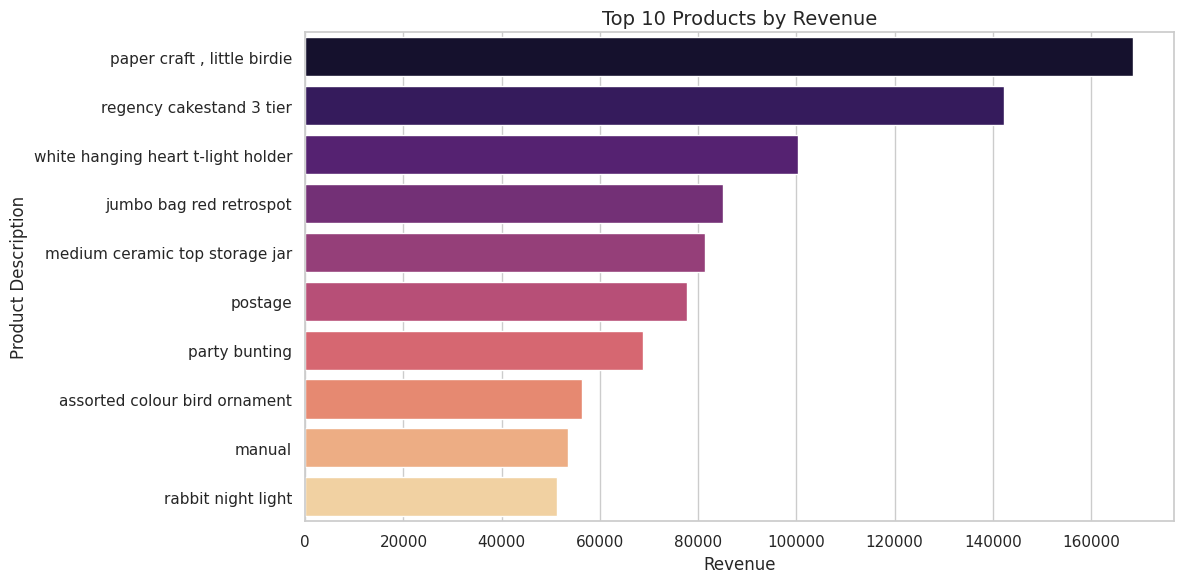

In [ ]:
# Top products by revenue
top_products = (
    df.groupby('Description', as_index=False)['Sales']
    .sum()
    .sort_values('Sales', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_products['Sales'],
    y=top_products['Description'],
    palette='magma'
)
plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()


###Top 10 Products by Quantity Sold

/tmp/ipython-input-517227176.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


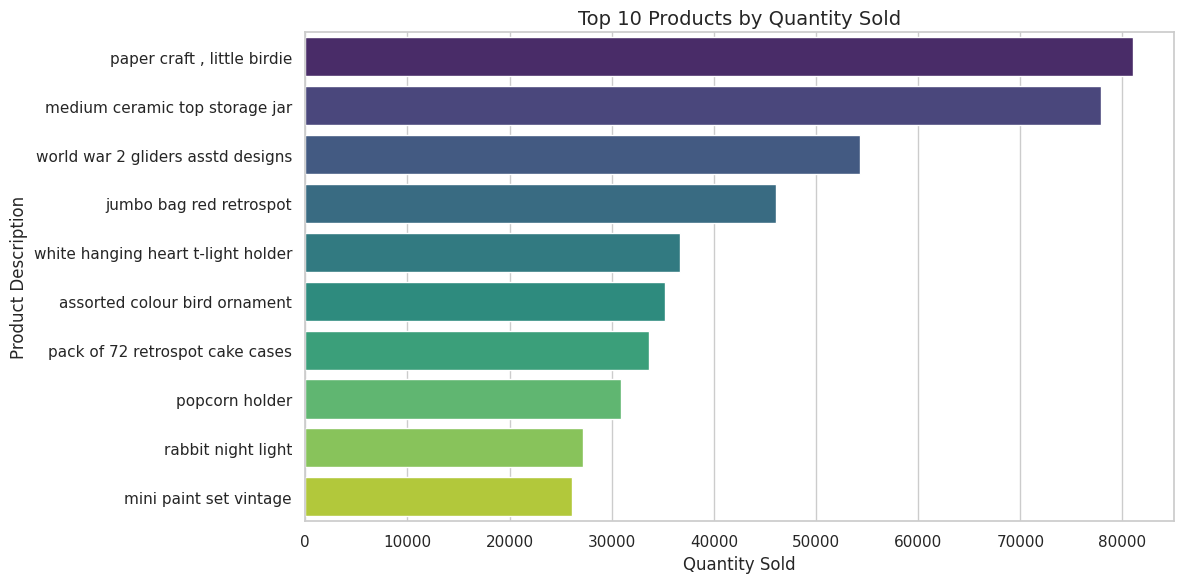

In [ ]:
top_quantity = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_quantity.values,
    y=top_quantity.index,
    palette='viridis'
)
plt.title("Top 10 Products by Quantity Sold", fontsize=14)
plt.xlabel("Quantity Sold")
plt.ylabel("Product Description")
plt.tight_layout()
plt.show()


###Top Countries by Revenue

/tmp/ipython-input-1077932425.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


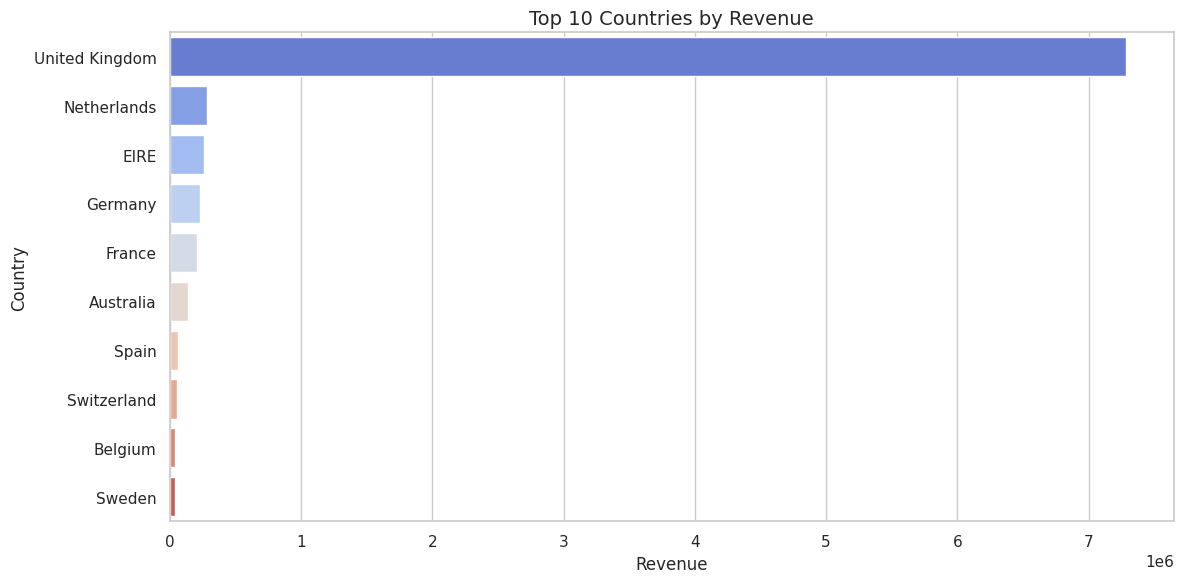

In [ ]:
country_rev = (
    df.groupby('Country', as_index=False)['Sales']
    .sum()
    .sort_values('Sales', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=country_rev['Sales'],
    y=country_rev['Country'],
    palette='coolwarm'
)
plt.title('Top 10 Countries by Revenue', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


###Top Customers (Lifetime Value)

/tmp/ipython-input-1901183207.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


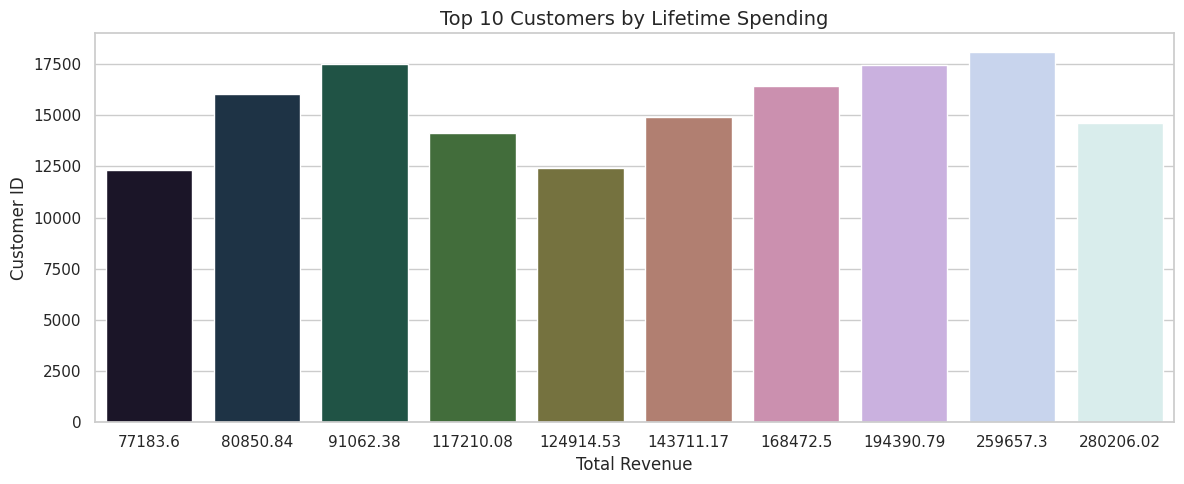

In [ ]:
top_customers = (
    df.groupby('CustomerID', as_index=False)['Sales']
    .sum()
    .sort_values('Sales', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))
sns.barplot(
    x=top_customers['Sales'],
    y=top_customers['CustomerID'],
    palette='cubehelix'
)
plt.title("Top 10 Customers by Lifetime Spending", fontsize=14)
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()


###Sales by Hour of Day

/tmp/ipython-input-3307711589.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


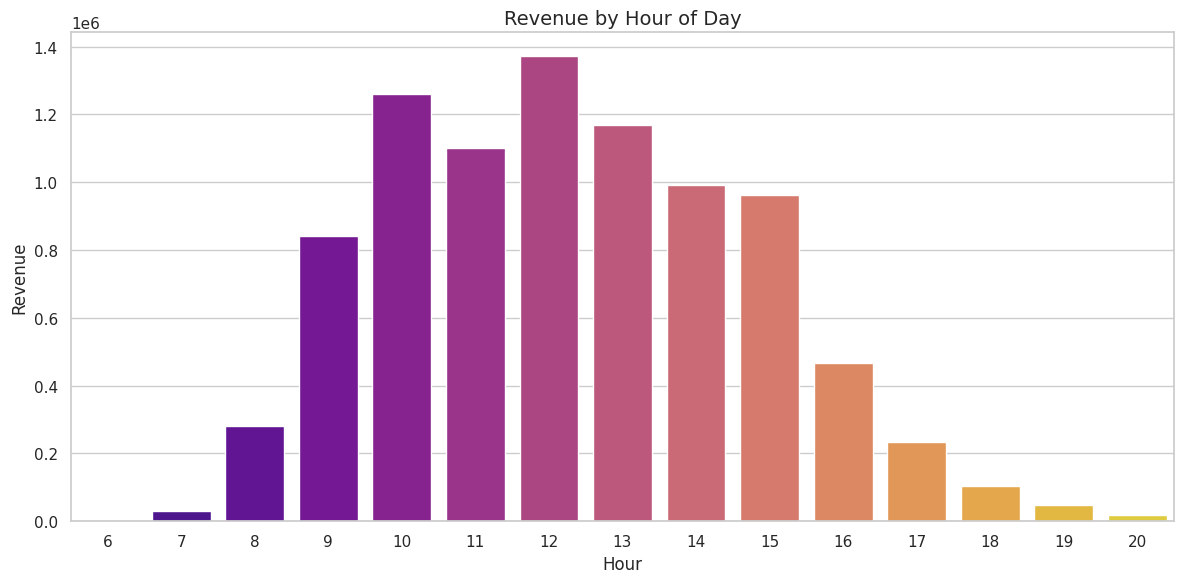

In [ ]:
hour_sales = df.groupby('InvoiceHour')['Sales'].sum()

plt.figure(figsize=(12,6))
sns.barplot(
    x=hour_sales.index,
    y=hour_sales.values,
    palette="plasma"
)
plt.title("Revenue by Hour of Day", fontsize=14)
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


###Daily Revenue Overtime

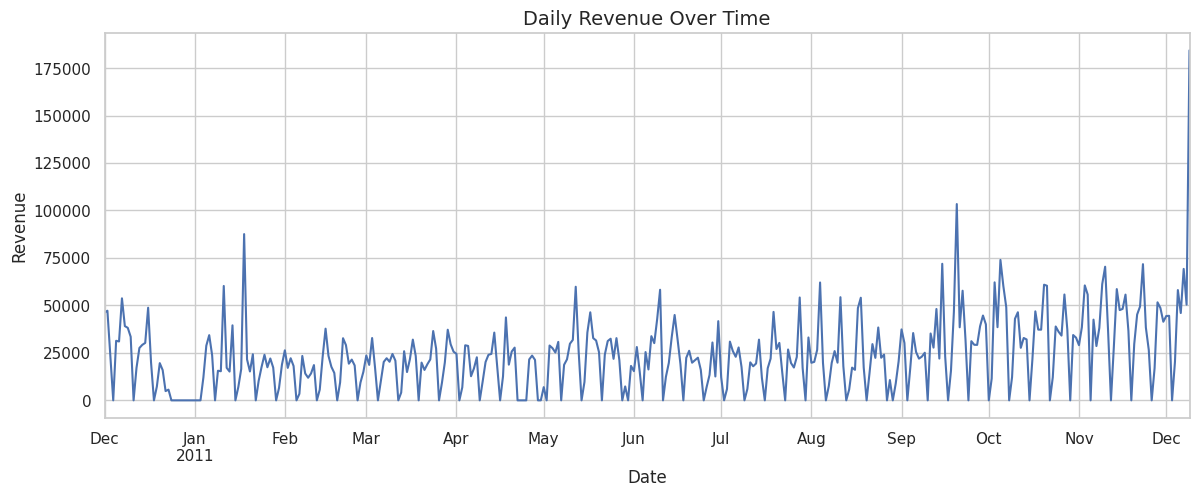

In [ ]:
daily_revenue = (
    df.set_index('InvoiceDate')
    .resample('D')['Sales']
    .sum()
)

plt.figure(figsize=(14,5))
daily_revenue.plot()
plt.title("Daily Revenue Over Time", fontsize=14)
plt.ylabel("Revenue")
plt.xlabel("Date")
plt.grid(True)
plt.show()


#Section 5: RFM & Customer Lifetime Value (CLV)

In [ ]:
"""## Section 5: RFM & Customer Lifetime Value (CLV)"""

from datetime import timedelta

# Snapshot date = 1 day after last purchase
snapshot_date = df["InvoiceDate"].max() + timedelta(days=1)

# Compute RFM per customer
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                                   # Frequency = number of orders
    "Sales": "sum"                                            # Monetary = total spend
}).rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "Sales": "Monetary"
})

# Simple CLV = same as monetary (total lifetime spending)
rfm["CLV"] = rfm["Monetary"]

rfm.head()


,Recency,Frequency,Monetary,CLV
CustomerID,,,,
12346,326,1,77183.60,77183.60
12347,2,7,4310.00,4310.00
12348,75,4,1797.24,1797.24
12349,19,1,1757.55,1757.55
12350,310,1,334.40,334.40


#Section 6: Statistical Inference (t-test)

In [ ]:
### T-test Between Regions

from scipy.stats import ttest_ind

country1 = "United Kingdom"
country2 = "Germany"

spend1 = df[df["Country"] == country1]["Sales"]
spend2 = df[df["Country"] == country2]["Sales"]

t_stat, p_value = ttest_ind(spend1, spend2, equal_var=False)

print(f"T-test between {country1} and {country2}")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("\n➡️ The difference **is statistically significant**.")
else:
    print("\n➡️ The difference is **NOT statistically significant**.")



T-test between United Kingdom and Germany
t-statistic: -6.685073576089653
p-value: 2.3226757687843805e-11

➡️ The difference **is statistically significant**.


In [ ]:
#Section 7: Logistic Regression

In [ ]:
"""## Section 8: Predicting Repeat Purchase (Logistic Regression)"""

# 1. Create binary target correctly (NO leakage)
rfm["RepeatPurchase"] = (rfm["Frequency"] > 1).astype(int)

# 2. USE ONLY NON-LEAKING FEATURES
# Frequency is NOT included because it defines the target.
# Recency is NOT included because it leaks future purchase timing.
X = rfm[["Monetary"]]   # cleanest, no leakage
y = rfm["RepeatPurchase"]

# 3. Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. No scaling needed for 1-column model, but it's okay if you want it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train logistic regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 6. Predictions
y_pred = model.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.67      0.71       299
           1       0.84      0.88      0.86       569

    accuracy                           0.81       868
   macro avg       0.79      0.78      0.78       868
weighted avg       0.80      0.81      0.81       868

Accuracy: 0.8076036866359447
Confusion Matrix:
 [[201  98]
 [ 69 500]]
